# CD2201-14 · Cátedra 1: Modelo Probabilista
**Profesores:** Matías Ortiz, Víctor Verdugo, José Correa  
**Fecha:** 05 de agosto de 2026

Este notebook acompaña los dos bloques de material computacional de la cátedra:
1. **Paradoja del cumpleaños** — cálculo exacto y visualización de $\mathbb{P}(A_n)$ y $\mathbb{P}(B_n)$.
2. **Simulación de Monty Hall** — Ley de Grandes Números en acción.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from math import comb

In [ ]:
plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 12,
})

---
## 1. Paradoja del cumpleaños

### Modelo
Hay $n$ personas. Cada una nace uniformemente en uno de 365 días, independientemente.  
$$\Omega = \{1,\ldots,365\}^n, \qquad |\Omega| = 365^n.$$

Definimos:
- $A_n$ = evento "todos los cumpleaños son distintos"
- $B_n = A_n^c$ = evento "al menos dos personas comparten cumpleaños"

### Fórmula exacta

Contamos $A_n$ por conteo directo: la primera persona puede nacer cualquier día (365 opciones), la segunda debe evitar el de la primera (364 opciones), etc.

$$\mathbb{P}(A_n) = \frac{365 \cdot 364 \cdots (365 - n + 1)}{365^n} = \prod_{k=0}^{n-1} \frac{365 - k}{365}$$

Por complemento:
$$\mathbb{P}(B_n) = 1 - \mathbb{P}(A_n) = 1 - \prod_{k=0}^{n-1} \frac{365 - k}{365}$$

**Pregunta:** ¿Para qué $n$ se cruza $\mathbb{P}(B_n) = 1/2$?

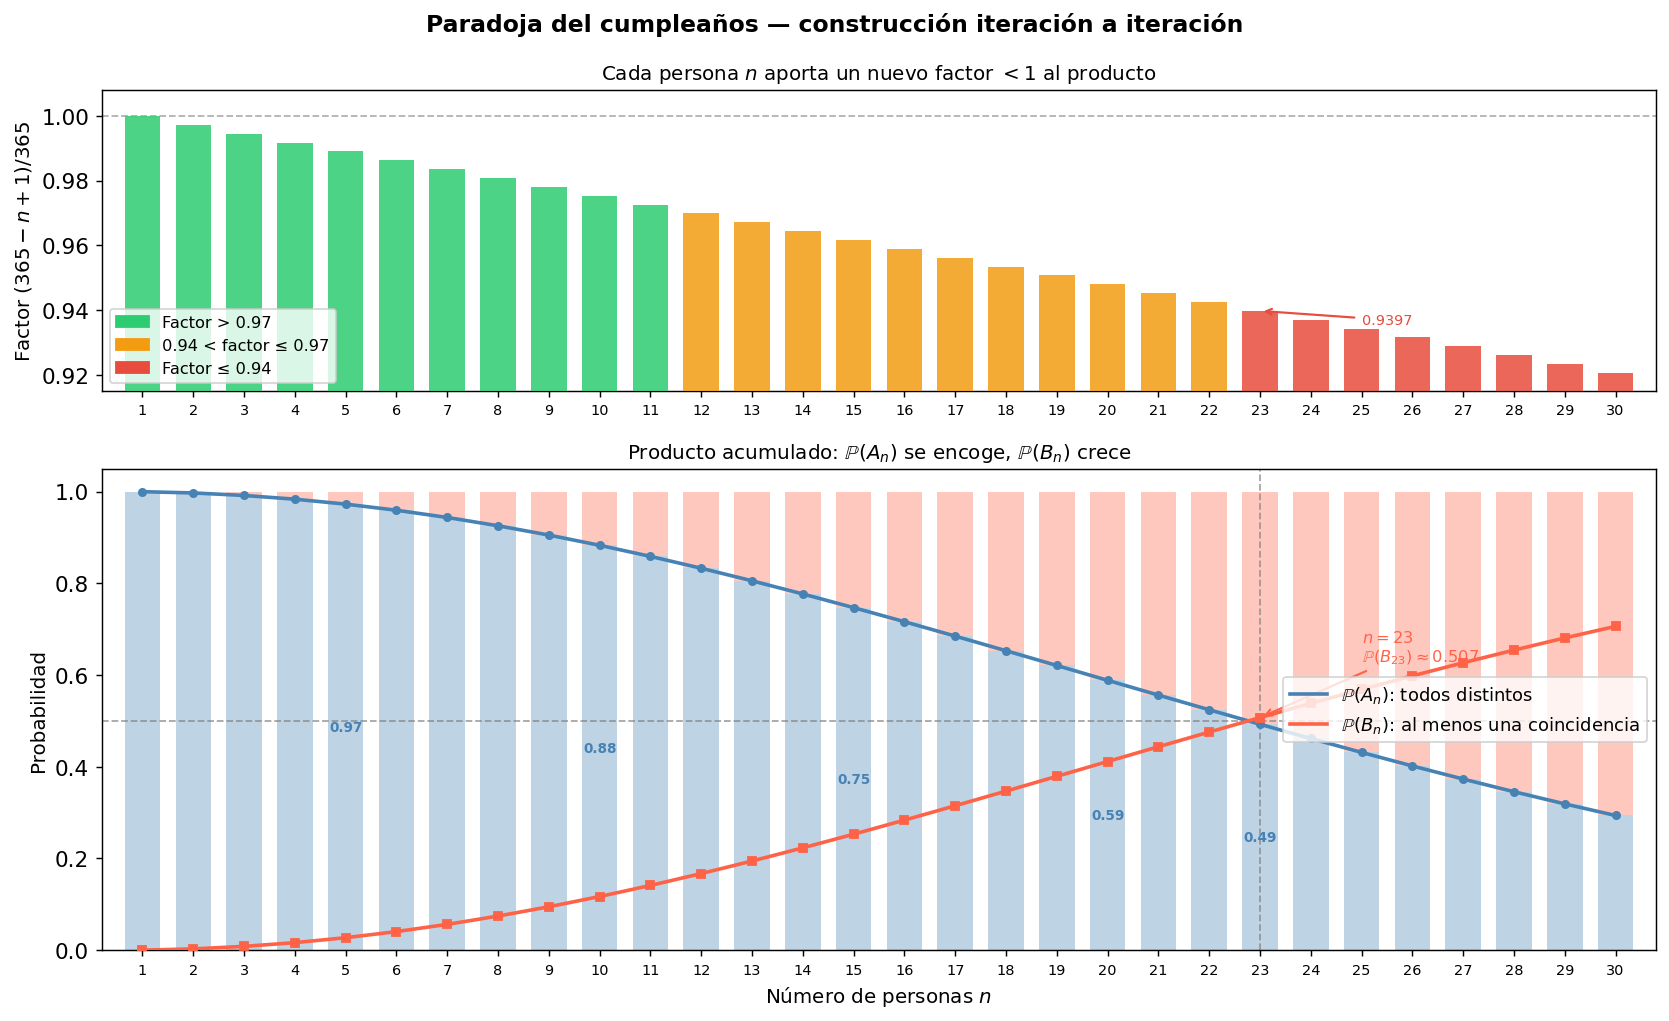

In [ ]:
def prob_todos_distintos(n, dias=365):
    resultado = 1.0
    for k in range(n):
        resultado *= (dias - k) / dias
    return resultado

ns      = np.arange(1, 81)
P_An    = np.array([prob_todos_distintos(n) for n in ns])
P_Bn    = 1 - P_An

n_cruce = ns[P_Bn >= 0.5][0]

pares   = np.array([comb(int(n), 2) for n in ns])

N_DEMO   = 30
personas = np.arange(1, N_DEMO + 1)

# La persona n debe evitar n-1 cumpleaños ya tomados: tiene (365-(n-1)) opciones libres de 365
factores   = (365 - (personas - 1)) / 365
prod_acum  = P_An[:N_DEMO]   # P(A_n): producto acumulado de los factores
prob_coinc = P_Bn[:N_DEMO]   # P(B_n): 1 - P(A_n)

fig, axes = plt.subplots(2, 1, figsize=(13, 8),
                         gridspec_kw={'height_ratios': [1, 1.6]})
fig.suptitle('Paradoja del cumpleaños — construcción iteración a iteración',
             fontsize=13, fontweight='bold')

# ── Panel superior: factor individual de cada persona ─────────────────────────
ax1 = axes[0]
colores_f = ['#2ecc71' if f > 0.97 else '#f39c12' if f > 0.94 else '#e74c3c'
             for f in factores]
ax1.bar(personas, factores, color=colores_f, alpha=0.85, width=0.7, zorder=3)
ax1.axhline(1.0, color='gray', lw=1, ls='--', alpha=0.6)
ax1.set_ylim(0.915, 1.008)
ax1.set_xlim(0.2, N_DEMO + 0.8)
ax1.set_ylabel(r'Factor $(365-n+1)/365$', fontsize=11)
ax1.set_title(r'Cada persona $n$ aporta un nuevo factor $< 1$ al producto',
              fontsize=11)
ax1.set_xticks(personas)
ax1.tick_params(axis='x', labelsize=8)

from matplotlib.patches import Patch
leyenda_f = [Patch(color='#2ecc71', label='Factor > 0.97'),
             Patch(color='#f39c12', label='0.94 < factor ≤ 0.97'),
             Patch(color='#e74c3c', label='Factor ≤ 0.94')]
ax1.legend(handles=leyenda_f, fontsize=9, loc='lower left')

primer_rojo = next(i for i, c in enumerate(colores_f) if c == '#e74c3c')
ax1.annotate(f'{factores[primer_rojo]:.4f}',
             xy=(personas[primer_rojo], factores[primer_rojo]),
             xytext=(personas[primer_rojo] + 2, factores[primer_rojo] - 0.004),
             arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.2),
             fontsize=8, color='#e74c3c')

# ── Panel inferior: producto acumulado ────────────────────────────────────────
ax2 = axes[1]
ax2.bar(personas, prod_acum, color='steelblue', alpha=0.35, width=0.7,
        label=r'$\mathbb{P}(A_n)$: todos distintos', zorder=2)
ax2.plot(personas, prod_acum, 'o-', color='steelblue', lw=2, ms=4, zorder=3)

ax2.bar(personas, prob_coinc, bottom=prod_acum, color='tomato', alpha=0.35, width=0.7,
        label=r'$\mathbb{P}(B_n)$: al menos una coincidencia', zorder=2)
ax2.plot(personas, prob_coinc, 's-', color='tomato', lw=2, ms=4, zorder=3)

ax2.axhline(0.5, color='gray', lw=1, ls='--', alpha=0.7)
ax2.axvline(n_cruce, color='gray', lw=1, ls='--', alpha=0.7)
ax2.annotate(
    f'$n={n_cruce}$\n'
    rf'$\mathbb{{P}}(B_{{{n_cruce}}})\approx{prob_coinc[n_cruce-1]:.3f}$',
    xy=(n_cruce, prob_coinc[n_cruce - 1]),
    xytext=(n_cruce + 2, 0.63),
    arrowprops=dict(arrowstyle='->', color='tomato', lw=1.2),
    fontsize=9, color='tomato'
)

for k in [5, 10, 15, 20, 23]:
    ax2.text(k, prod_acum[k-1] / 2, f'{prod_acum[k-1]:.2f}',
             ha='center', va='center', fontsize=7.5,
             color='steelblue', fontweight='bold')

ax2.set_xlim(0.2, N_DEMO + 0.8)
ax2.set_ylim(0, 1.05)
ax2.set_xlabel('Número de personas $n$', fontsize=11)
ax2.set_ylabel('Probabilidad', fontsize=11)
ax2.set_title(r'Producto acumulado: $\mathbb{P}(A_n)$ se encoge, $\mathbb{P}(B_n)$ crece',
              fontsize=11)
ax2.set_xticks(personas)
ax2.tick_params(axis='x', labelsize=8)
ax2.legend(handles=[
    plt.Line2D([0], [0], color='steelblue', lw=2, label=r'$\mathbb{P}(A_n)$: todos distintos'),
    plt.Line2D([0], [0], color='tomato',    lw=2, label=r'$\mathbb{P}(B_n)$: al menos una coincidencia'),
], fontsize=10, loc='center right')

plt.tight_layout()
plt.show()

<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_508/883335930.py:11: SyntaxWarning: invalid escape sequence '\m'
  f'$n={n_cruce}$\n$\mathbb{{P}}(B_{{23}})\\approx{P_Bn[n_cruce-1]:.3f}$',
/tmp/ipykernel_508/883335930.py:19: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title('Probabilidades $\mathbb{P}(A_n)$ y $\mathbb{P}(B_n)$')


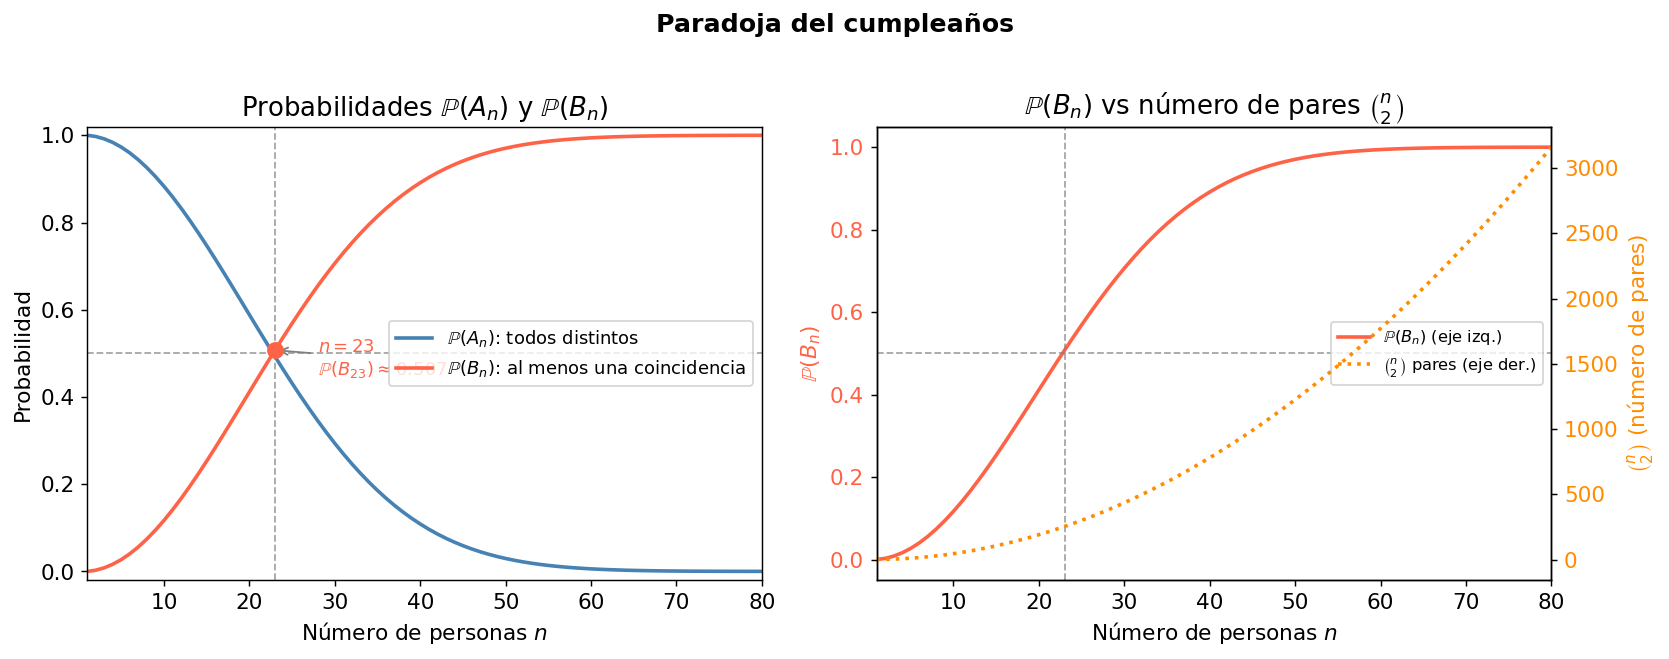

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel izquierdo: P(A_n) y P(B_n) ──────────────────────────────────────────
ax = axes[0]
ax.plot(ns, P_An, color='steelblue', lw=2, label=r'$\mathbb{P}(A_n)$: todos distintos')
ax.plot(ns, P_Bn, color='tomato',    lw=2, label=r'$\mathbb{P}(B_n)$: al menos una coincidencia')
ax.axhline(0.5, color='gray', lw=1, ls='--', alpha=0.7)
ax.axvline(n_cruce, color='gray', lw=1, ls='--', alpha=0.7)
ax.scatter([n_cruce], [P_Bn[n_cruce-1]], zorder=5, color='tomato', s=70)
ax.annotate(
    f'$n={n_cruce}$\n$\mathbb{{P}}(B_{{23}})\\approx{P_Bn[n_cruce-1]:.3f}$',
    xy=(n_cruce, P_Bn[n_cruce-1]),
    xytext=(n_cruce + 5, 0.45),
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=10, color='tomato'
)
ax.set_xlabel('Número de personas $n$')
ax.set_ylabel('Probabilidad')
ax.set_title('Probabilidades $\mathbb{P}(A_n)$ y $\mathbb{P}(B_n)$')
ax.legend(fontsize=10)
ax.set_xlim(1, 80)
ax.set_ylim(-0.02, 1.02)

# ── Panel derecho: P(B_n) vs número de pares C(n,2) ───────────────────────────
ax2 = axes[1]
color_prob  = 'tomato'
color_pares = 'darkorange'

ax2.plot(ns, P_Bn, color=color_prob, lw=2, label=r'$\mathbb{P}(B_n)$ (eje izq.)')
ax2.axhline(0.5, color='gray', lw=1, ls='--', alpha=0.7)
ax2.axvline(n_cruce, color='gray', lw=1, ls='--', alpha=0.7)
ax2.set_xlabel('Número de personas $n$')
ax2.set_ylabel(r'$\mathbb{P}(B_n)$', color=color_prob)
ax2.tick_params(axis='y', labelcolor=color_prob)
ax2.set_xlim(1, 80)

ax3 = ax2.twinx()
ax3.plot(ns, pares, color=color_pares, lw=2, ls=':', label=r'$\binom{n}{2}$ pares (eje der.)')
ax3.set_ylabel(r'$\binom{n}{2}$ (número de pares)', color=color_pares)
ax3.tick_params(axis='y', labelcolor=color_pares)
ax3.spines['right'].set_visible(True)

ax2.set_title(r'$\mathbb{P}(B_n)$ vs número de pares $\binom{n}{2}$')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='center right')

fig.suptitle('Paradoja del cumpleaños', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Tabla de valores clave (reproduce la tabla de la cátedra)
print(f"{'n':>4}  {'C(n,2)':>7}  {'P(B_n)':>8}")
print('-' * 25)
for n in [5, 10, 15, 20, 23, 30, 40, 50]:
    p = 1 - prob_todos_distintos(n)
    print(f"{n:>4}  {comb(n,2):>7}  {p:>8.3f}")

   n   C(n,2)    P(B_n)
-------------------------
   5       10     0.027
  10       45     0.117
  15      105     0.253
  20      190     0.411
  23      253     0.507
  30      435     0.706
  40      780     0.891
  50     1225     0.970


**Comentario.** La intuición ve $n$ individuos comparados contra 365 días y estima que se necesitan ~183 personas. El cálculo ve $\binom{n}{2}$ pares: con $n=23$ ya hay 253 pares compitiendo contra 365 días posibles, y eso basta para que la coincidencia sea más probable que su complemento.

---
## 2. Simulación de Monty Hall — Ley de Grandes Números

### Derivación del algoritmo (antes del código)

Antes de escribir una línea, pensemos qué debe hacer la simulación.

**Una corrida del juego:**
1. Ubicar el premio uniformemente en una de las tres puertas.
2. El jugador elige la puerta 1 (sin pérdida de generalidad).
3. El animador abre una puerta vacía distinta de la elegida (respetando el modelo: sabe dónde está el premio).
4. Registrar si la estrategia **cambiar** gana en esta corrida.

**¿Cuándo gana la estrategia de cambiar?**  
Exactamente cuando el premio **no** está en la puerta elegida inicialmente. Si el premio está en 1, cambiar pierde. Si está en 2 o 3, cambiar gana (el animador nos señala implícitamente la puerta ganadora al eliminar la otra).

Entonces ni siquiera necesitamos simular qué puerta abre el animador: basta verificar si el premio está en la puerta inicial.

**Estimador empírico:**  
Sea $X_i = 1$ si en la corrida $i$ se gana cambiando. La Ley de Grandes Números garantiza:
$$\hat{p}_n = \frac{1}{n}\sum_{i=1}^n X_i \xrightarrow{n\to\infty} \mathbb{P}(\text{ganar cambiando}) = \frac{2}{3}$$

In [ ]:
rng = np.random.default_rng(seed=42)

N = 10_000  # número de corridas

# Premio en puerta 1, 2 o 3 con igual probabilidad
premio = rng.integers(1, 4, size=N)   # array de N valores en {1, 2, 3}

# El jugador elige la puerta 1 siempre.
# Cambiar gana ⟺ el premio NO está en la puerta 1.
gana_cambiando = (premio != 1).astype(float)   # 1 si gana, 0 si no

# Frecuencia relativa acumulada
p_hat = np.cumsum(gana_cambiando) / np.arange(1, N + 1)

print(f"Frecuencia empírica tras {N:,} corridas: {p_hat[-1]:.4f}")
print(f"Valor teórico: 2/3 ≈ {2/3:.4f}")
print(f"Error: {abs(p_hat[-1] - 2/3):.4f}")

Frecuencia empírica tras 10,000 corridas: 0.6601
Valor teórico: 2/3 ≈ 0.6667
Error: 0.0066


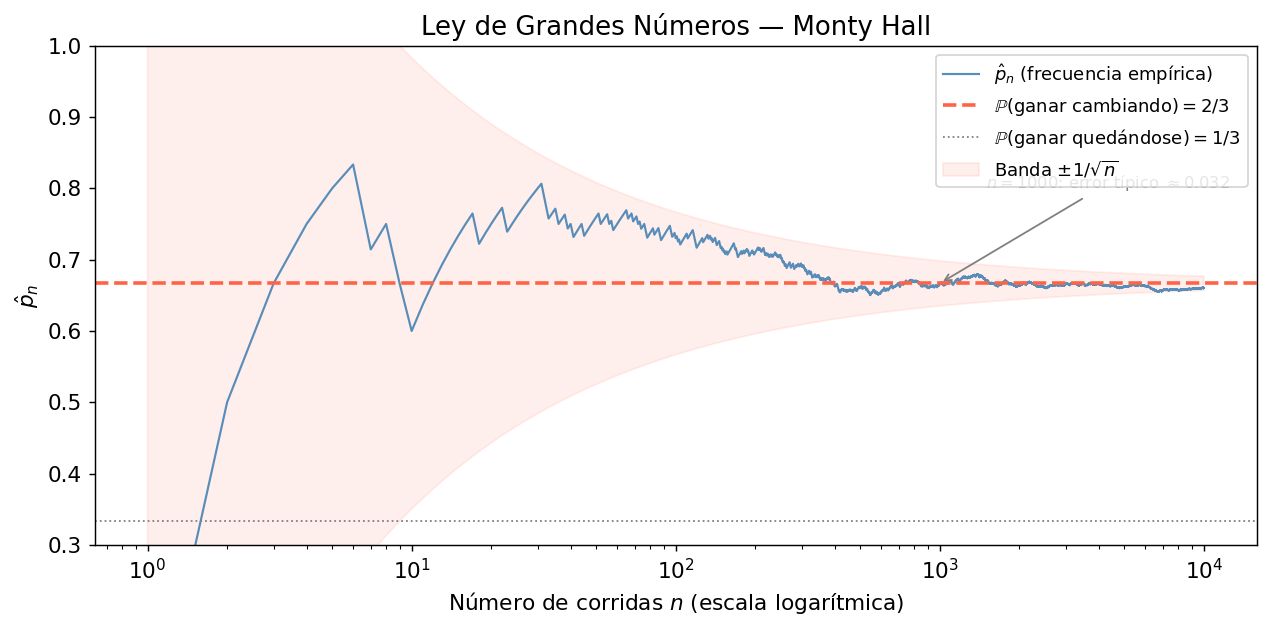

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ns_plot = np.arange(1, N + 1)
ax.plot(ns_plot, p_hat, color='steelblue', lw=1.2, alpha=0.9, label=r'$\hat{p}_n$ (frecuencia empírica)')
ax.axhline(2/3, color='tomato', lw=2, ls='--', label=r'$\mathbb{P}(\text{ganar cambiando}) = 2/3$')
ax.axhline(1/3, color='gray',   lw=1, ls=':',  label=r'$\mathbb{P}(\text{ganar quedándose}) = 1/3$')

# Banda de error típico ±1/√n
error = 1 / np.sqrt(ns_plot)
ax.fill_between(ns_plot, 2/3 - error, 2/3 + error, color='tomato', alpha=0.10, label=r'Banda $\pm 1/\sqrt{n}$')

ax.set_xscale('log')
ax.set_xlabel('Número de corridas $n$ (escala logarítmica)')
ax.set_ylabel(r'$\hat{p}_n$')
ax.set_title('Ley de Grandes Números — Monty Hall')
ax.set_ylim(0.3, 1.0)
ax.legend(fontsize=10)

# Anotar error típico en n=1000
ax.annotate(
    f'$n=1000$: error típico $\\approx {1/np.sqrt(1000):.3f}$',
    xy=(1000, 2/3),
    xytext=(1500, 0.80),
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=9, color='gray'
)

plt.tight_layout()
plt.show()

**Comentario.** La banda $\pm 1/\sqrt{n}$ corresponde al error estándar del estimador. Con $n=1000$, el error típico es $\approx 0.032$: un resultado como $0.641$ o $0.691$ no contradice el cálculo teórico, es fluctuación normal. La simulación no reemplaza la demostración, pero permite verificar la estructura del problema e intuir el resultado antes de calcularlo.

---
## Bonus: simulación explícita (con el animador)

La versión vectorizada es eficiente pero opaca: corre 10.000 juegos de golpe y entrega un número.
Aquí se simula el juego completo **corrida a corrida**, mostrando cada resultado individual
y cómo la frecuencia acumulada converge a $2/3$ y $1/3$.

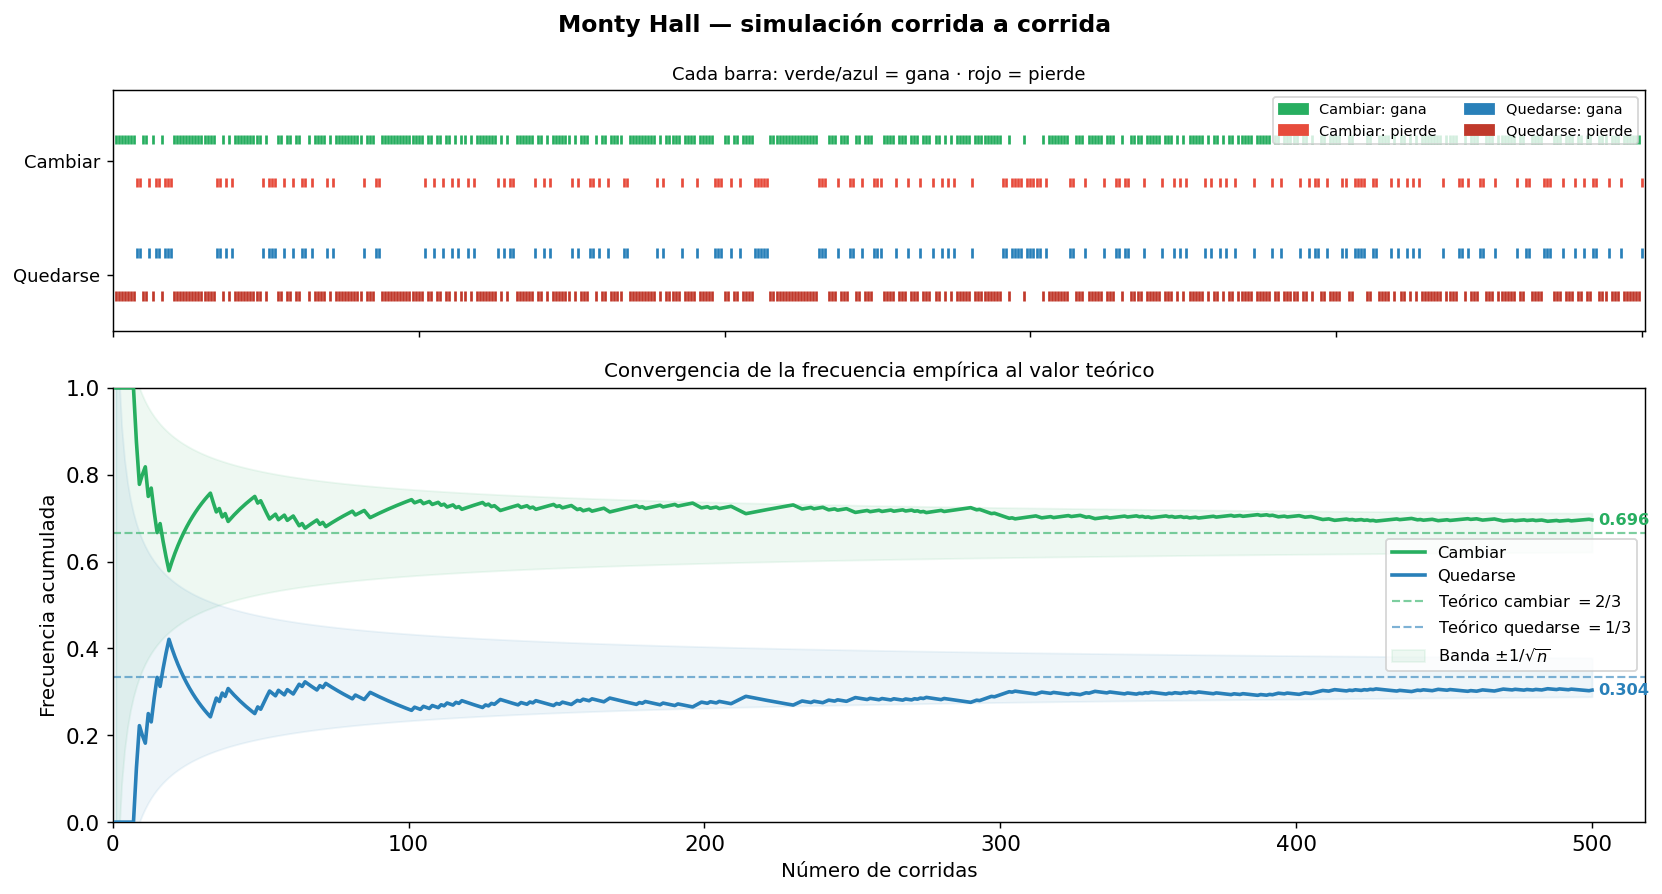


Frecuencia final  cambiar : 0.6960  (teórico: 0.6667)
Frecuencia final quedarse: 0.3040  (teórico: 0.3333)


In [ ]:
def simular_monty_hall(n_corridas, seed=7):
    """
    Simula n_corridas del juego completo, incluyendo la apertura del animador.
    Devuelve dos arrays: resultados_cambiar y resultados_quedarse (1=gana, 0=pierde).
    """
    rng = np.random.default_rng(seed)
    puertas = [1, 2, 3]
    res_cambiar  = np.empty(n_corridas, dtype=int)
    res_quedarse = np.empty(n_corridas, dtype=int)

    for i in range(n_corridas):
        premio   = rng.choice(puertas)
        eleccion = 1

        # Animador abre una puerta vacía distinta de la elegida
        candidatas = [p for p in puertas if p != eleccion and p != premio]
        abre = rng.choice(candidatas)

        # Estrategias
        nueva = [p for p in puertas if p != eleccion and p != abre][0]
        res_cambiar[i]  = int(nueva  == premio)
        res_quedarse[i] = int(eleccion == premio)

    return res_cambiar, res_quedarse


N_SIM = 500
rc, rq = simular_monty_hall(N_SIM)

freq_c = np.cumsum(rc) / np.arange(1, N_SIM + 1)
freq_q = np.cumsum(rq) / np.arange(1, N_SIM + 1)
corridas = np.arange(1, N_SIM + 1)

# ── Figura ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 7),
                         gridspec_kw={'height_ratios': [1, 1.8]})
fig.suptitle('Monty Hall — simulación corrida a corrida', fontsize=13, fontweight='bold')

# ── Panel superior: resultado de cada juego ───────────────────────────────────
ax1 = axes[0]

# Estrategia cambiar: marcas verdes (gana) y rojas (pierde)
yc = np.where(rc == 1, 1.15, 0.85)
colores_c = ['#27ae60' if r == 1 else '#e74c3c' for r in rc]
ax1.scatter(corridas, yc, c=colores_c, s=28, marker='|', linewidths=1.5, zorder=3)

# Estrategia quedarse: marcas en fila inferior
yq = np.where(rq == 1, 0.35, 0.05)
colores_q = ['#2980b9' if r == 1 else '#c0392b' for r in rq]
ax1.scatter(corridas, yq, c=colores_q, s=28, marker='|', linewidths=1.5, zorder=3)

ax1.set_yticks([1.0, 0.2])
ax1.set_yticklabels(['Cambiar', 'Quedarse'], fontsize=10)
ax1.set_xlim(0, N_SIM + 1)
ax1.set_ylim(-0.2, 1.5)
ax1.set_title('Cada barra: verde/azul = gana · rojo = pierde', fontsize=10)
ax1.tick_params(axis='x', labelbottom=False)

from matplotlib.patches import Patch
leyenda_top = [Patch(color='#27ae60', label='Cambiar: gana'),
               Patch(color='#e74c3c', label='Cambiar: pierde'),
               Patch(color='#2980b9', label='Quedarse: gana'),
               Patch(color='#c0392b', label='Quedarse: pierde')]
ax1.legend(handles=leyenda_top, fontsize=8, loc='upper right', ncol=2)

# ── Panel inferior: frecuencia acumulada ──────────────────────────────────────
ax2 = axes[1]

ax2.plot(corridas, freq_c, color='#27ae60', lw=2,   label='Cambiar', zorder=3)
ax2.plot(corridas, freq_q, color='#2980b9', lw=2,   label='Quedarse', zorder=3)
ax2.axhline(2/3, color='#27ae60', lw=1.2, ls='--', alpha=0.6,
            label=r'Teórico cambiar $= 2/3$')
ax2.axhline(1/3, color='#2980b9', lw=1.2, ls='--', alpha=0.6,
            label=r'Teórico quedarse $= 1/3$')

# Banda ±1/√n alrededor de 2/3
banda = 1 / np.sqrt(corridas)
ax2.fill_between(corridas, 2/3 - banda, 2/3 + banda,
                 color='#27ae60', alpha=0.08, label=r'Banda $\pm 1/\sqrt{n}$')
ax2.fill_between(corridas, 1/3 - banda, 1/3 + banda,
                 color='#2980b9', alpha=0.08)

# Anotar valores finales
ax2.text(N_SIM + 2, freq_c[-1], f'{freq_c[-1]:.3f}', va='center',
         fontsize=9, color='#27ae60', fontweight='bold')
ax2.text(N_SIM + 2, freq_q[-1], f'{freq_q[-1]:.3f}', va='center',
         fontsize=9, color='#2980b9', fontweight='bold')

ax2.set_xlim(0, N_SIM + 18)
ax2.set_ylim(0.0, 1.0)
ax2.set_xlabel('Número de corridas', fontsize=11)
ax2.set_ylabel('Frecuencia acumulada', fontsize=11)
ax2.set_title('Convergencia de la frecuencia empírica al valor teórico', fontsize=11)
ax2.legend(fontsize=9, loc='center right')

plt.tight_layout()
plt.show()

print(f"\nFrecuencia final  cambiar : {freq_c[-1]:.4f}  (teórico: {2/3:.4f})")
print(f"Frecuencia final quedarse: {freq_q[-1]:.4f}  (teórico: {1/3:.4f})")